# 04: 量子フーリエ変換 (QFT) — 回路の実装

ノート `04_discrete_fourier_transform.md` で導入した離散フーリエ変換 (DFT) を、量子回路として実現する。

**内容:**
1. $N = 2$（1量子ビット）の QFT — アダマールゲートとの一致
2. Qiskit の `QFTGate` で具体例を確認

> **記法の注意:** ノートと Qiskit ではインデックスの始まり（1 vs 0）やケット表記のビット順が異なる。詳しくは [01_qubit_ordering.ipynb](01_qubit_ordering.ipynb) を参照。物理的な結果には影響しない。

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate
import numpy as np

## 1. $N = 2$（1量子ビット）の QFT

ノート04で示した通り、$N = 2$ の DFT 行列は：

$$
F_2 = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}
$$

これはアダマールゲート $H$ そのものである。1量子ビットの QFT は $H$ ゲート1つで実現できる。

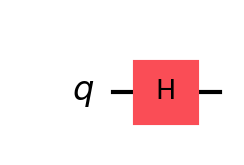

In [14]:
# 1量子ビットの QFT = アダマールゲート
qc_qft1 = QuantumCircuit(1)
qc_qft1.h(0)

print(f"1量子ビット QFT 回路: ゲート数 {qc_qft1.size()}")

1量子ビット QFT 回路: ゲート数 1


In [3]:
# H ゲートの行列を確認
H_matrix = Operator(qc_qft1).data
print("H ゲートの行列:")
print(np.array(H_matrix).round(4))

# F_2 を手計算で構築
F2 = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]])
print("\nF_2（DFT 行列）:")
print(F2.round(4))

print(f"\n一致するか: {np.allclose(H_matrix, F2)}")
print("→ 1量子ビットの QFT はアダマールゲートそのもの。")

H ゲートの行列:
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

F_2（DFT 行列）:
[[ 0.7071  0.7071]
 [ 0.7071 -0.7071]]

一致するか: True
→ 1量子ビットの QFT はアダマールゲートそのもの。


**コードの解説:**

- `Operator(qc_qft1)`: 量子回路を**ユニタリ行列**（演算子）として扱うためのクラス。回路がどんなゲートの列であっても、全体を1つの行列にまとめてくれる。`Statevector` が「状態」を表すのに対し、`Operator` は「操作」を表す。
- `.data`: `Operator` が保持するユニタリ行列を NumPy 配列として取得する。1量子ビットなら $2 \times 2$、2量子ビットなら $4 \times 4$ の行列が得られる。
- `np.allclose`: 2つの行列が数値的に一致するか判定する（浮動小数点の誤差を許容）。

## 2. Qiskit の `QFTGate` で具体例を確認

Qiskit には `QFTGate` クラスが用意されている。後続の QPE（notebook 05）や Shor のアルゴリズム（notebook 06）では、このライブラリを使って逆 QFT を適用する。

ここではノート04で手計算した3つの例を、`QFTGate` を使ったシミュレーションで確認する。

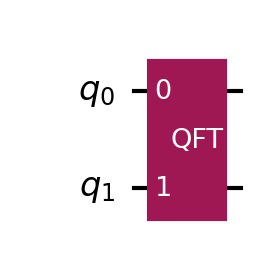

In [22]:
# Qiskit の QFTGate（2量子ビット）
qft_lib = QFTGate(2)

print(f"Qiskit QFTGate: {qft_lib.num_qubits} 量子ビット")

Qiskit QFTGate: 2 量子ビット


**コードの解説:**

- `QFTGate(2)`: 2量子ビットの QFT ゲートを生成する。引数はビット数。
- `QFTGate(2).inverse()` とすれば逆 QFT（$F_N^\dagger$）が得られる。QPE（ノート05）で使用する。
- `qc.initialize(input_vec, [0, 1])`: $q_0$ と $q_1$ の2量子ビット全体を `input_vec` で指定した状態に初期化する。`[0, 1]` は使用する量子ビット、`input_vec` はその $2^2 = 4$ 次元の状態ベクトルである。例えば `[0.5, 0.5, 0.5, 0.5]` なら $0.5|00\rangle + 0.5|01\rangle + 0.5|10\rangle + 0.5|11\rangle$ を準備する。

In [21]:
def apply_qft_and_show(input_vec, label):
    """入力状態に QFT を適用し、結果を表示する。"""
    qc = QuantumCircuit(2)
    qc.initialize(input_vec, [0, 1])
    # QFTGate を適用
    qc.append(QFTGate(2), [0, 1])
    
    sv = Statevector.from_instruction(qc)
    
    print(f"入力: {label}")
    print(f"  入力ベクトル: {np.array(input_vec).round(4)}")
    print(f"  QFT 出力:     {np.array(sv).round(4)}")
    print()


# 計算例 1: 一様分布 — 均等な入力 (1/2, 1/2, 1/2, 1/2)
apply_qft_and_show([0.5, 0.5, 0.5, 0.5], "|x⟩ = (1/2)(|0⟩+|1⟩+|2⟩+|3⟩)")

# 計算例 2: 交互のパターン — (1/2, -1/2, 1/2, -1/2)
apply_qft_and_show([0.5, -0.5, 0.5, -0.5], "|x⟩ = (1/2)(|0⟩-|1⟩+|2⟩-|3⟩)")

# 計算例 3: 単一成分 — |0⟩ だけ（デルタ関数）
apply_qft_and_show([1, 0, 0, 0], "|x⟩ = |0⟩")

入力: |x⟩ = (1/2)(|0⟩+|1⟩+|2⟩+|3⟩)
  入力ベクトル: [0.5 0.5 0.5 0.5]
  QFT 出力:     [ 1.+0.j -0.+0.j  0.+0.j  0.+0.j]

入力: |x⟩ = (1/2)(|0⟩-|1⟩+|2⟩-|3⟩)
  入力ベクトル: [ 0.5 -0.5  0.5 -0.5]
  QFT 出力:     [ 0.+0.j  0.+0.j  1.-0.j -0.+0.j]

入力: |x⟩ = |0⟩
  入力ベクトル: [1 0 0 0]
  QFT 出力:     [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]

